### EDA

In [1]:
import pandas as pd

In [2]:
all_data = pd.read_csv('./data/quotes.csv')
all_data = all_data.sample(n=10**4, random_state=42).reset_index(drop=True)

In [3]:
all_data.head()

,quote,author,category
0,The sting of her abandonment had not lessened ...,"T.J. Forrester, Miracles, Inc.: A Novel","love, relationship, suffering"
1,Everything that falls upon the eye is an appar...,Marilynn Robinson in Housekeeping,"grief, loss, memory, remembering-the-good, time"
2,I don't hate Republicans as individuals. But I...,Howard Dean,"politics, republicans"
3,Think More Not Less.,Jelani Payne,"critical-thinking, perspective"
4,"Some individuals have the courage to make it, ...","Gino Segrè, Ordinary Geniuses: Max Delbruck, G...","comfortable, dream, inspirational, journey, jo..."


In [4]:
all_data.shape

(10000, 3)

In [5]:
all_values = all_data['category'].str.split(', ').explode()
frequency_counts = all_values.value_counts()
frequency_counts = pd.DataFrame(frequency_counts).reset_index()
frequency_counts['cumulative_cnt'] = frequency_counts['count'].cumsum()
# threshold = frequency_counts.iloc[-1,:]['cumulative_cnt'] * 0.

In [6]:
frequency_counts.head(10)

,category,count,cumulative_cnt
0,love,772,772
1,life,713,1485
2,inspirational,552,2037
3,philosophy,291,2328
4,god,248,2576
5,truth,244,2820
6,humor,242,3062
7,happiness,225,3287
8,wisdom,208,3495
9,quotes,195,3690


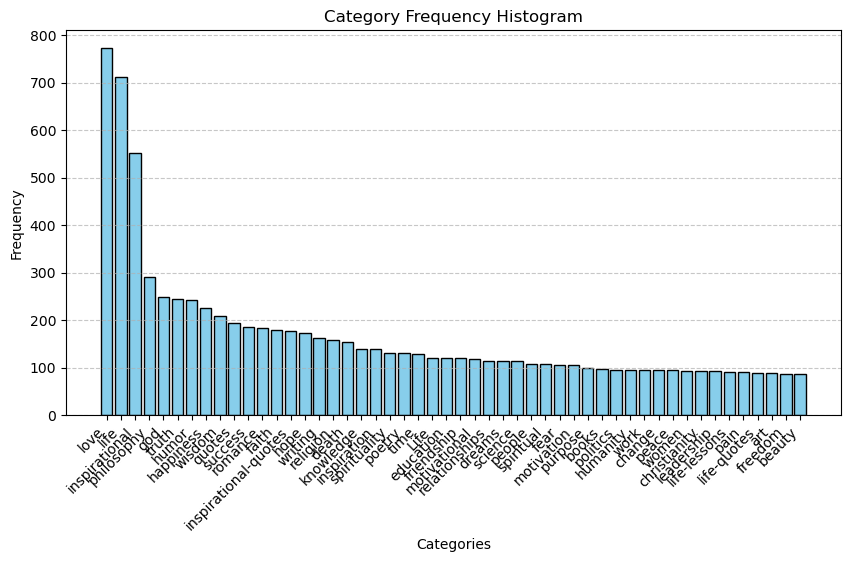

In [7]:
import matplotlib.pyplot as plt

# Clip small frequency counts (set minimum count threshold)
# min_threshold = 10  # Adjust this threshold as needed
filtered_counts = frequency_counts[frequency_counts.index<50]

# Plot histogram
plt.figure(figsize=(10, 5))
# filtered_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.bar(filtered_counts['category'], filtered_counts['count'], color='skyblue', edgecolor='black')

# Customize plot
plt.xlabel("Categories")
plt.ylabel("Frequency")
plt.title("Category Frequency Histogram")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

### Embeddings + Metadata Creation

In [ ]:
!pip install -U sentence-transformers, pinecone-client, spacy, rake-nltk, nltk, contractions, keybert

In [51]:
from sentence_transformers import SentenceTransformer
import spacy
from nltk.sentiment import SentimentIntensityAnalyzer
import os
from dotenv import load_dotenv
load_dotenv('env')
import nltk
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
nltk.download('stopwords')  # Required for Rake's keyword extraction
nltk.download('punkt')      
nltk.download('vader_lexicon')
nltk.download('wordnet')

In [ ]:
! python -m spacy download en_core_web_sm

In [19]:
import re
import contractions
import unicodedata

def normalize_quote(text):
    """
    Cleans quote text while preserving semantic-critical punctuation and case.
    """
    # Fix Unicode (e.g., “ → ")
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    
    # Remove URLs, HTML, social tags
    text = re.sub(r'http\S+|www\S+|https\S+|@\w+|#\w+', '', text)
    
    # Expand contractions (optional, but improves consistency)
    text = contractions.fix(text)
    
    # Remove unwanted symbols (keep .!?,;:'"-)
    text = re.sub(r'[^\w\s.!?,;:\'\"-]', '', text)
    
    # Trim whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


raw_text = "Don't stop believin’! 🎤 Check this out: https://example.com #music"
cleaned = normalize_quote(raw_text)
print(cleaned)  # Output: "do not stop believing check this out music"

Do not stop believin! Check this out:


In [21]:
all_data['quote_norm'] = all_data['quote'].apply(lambda x:normalize_quote(x)) # + '\n - ' + all_data['author'] 
all_data['quote_norm'].head()

0    The sting of her abandonment had not lessened ...
1    Everything that falls upon the eye is an appar...
2    I do not hate Republicans as individuals. But ...
3                                 Think More Not Less.
4    Some individuals have the courage to make it, ...
Name: quote_norm, dtype: object

In [41]:
from pinecone import ServerlessSpec, Pinecone

pc = Pinecone(api_key=os.environ.get("PINECONE_KEYS1"))
index_name = "quotes-index"

if index_name not in [x['name'] for x in pc.list_indexes().to_dict()['indexes']]:
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(
            cloud='aws', 
            region='us-east-1'
        ) 
    ) 

# Wait for the index to be ready
while not pc.describe_index(index_name).status['ready']:
    time.sleep(1)

index = pc.Index(index_name)

In [43]:
# metadata keywords created earlier were pretty bad; enhancing it
def lemmatize_keywords(keywords):
    doc = nlp(" ".join(keywords))
    return [token.lemma_ for token in doc]

In [45]:
from nltk.corpus import wordnet

def group_synonyms(keywords):
    synonym_groups = {}
    for keyword in keywords:
        synsets = wordnet.synsets(keyword)
        if synsets:
            # Use the first synset's name as the group key
            group_key = synsets[0].name().split('.')[0]
            if group_key not in synonym_groups:
                synonym_groups[group_key] = []
            synonym_groups[group_key].append(keyword)
    # Choose the most frequent word in each group as the representative
    return [max(group, key=len) for group in synonym_groups.values()]

In [47]:
from keybert import KeyBERT

kw_model = KeyBERT()

def extract_keybert_keywords(text, top_n=5):
    keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=top_n)
    return [kw[0] for kw in keywords]  # Extract the keyword phrases


In [48]:
from spacy.lang.en.stop_words import STOP_WORDS

def enhance_keywords(text):
    # Step 1: Extract keywords (e.g., using KeyBERT)
    keywords = extract_keybert_keywords(text)
    
    # Step 2: Lemmatize
    keywords = lemmatize_keywords(keywords)
    
    # Step 3: Deduplicate and lowercase
    keywords = list(set([keyword.lower() for keyword in keywords]))
    
    # Step 4: Filter stopwords
    keywords = [keyword for keyword in keywords if keyword not in STOP_WORDS]
    
    # Step 5: Group synonyms
    keywords = group_synonyms(keywords)
    
    return keywords

In [53]:
sample_sentence = 'Reality is wrong. Dreams are for real'

enhance_keywords(sample_sentence)

['dream', 'real', 'wrong', 'reality']

In [55]:
# Initialize models
model = SentenceTransformer('all-MiniLM-L6-v2')
sia = SentimentIntensityAnalyzer()

In [57]:
def process_quotes(quotes, batch_size=100):
    for i in range(0, len(quotes), batch_size):
        batch = quotes[i:i+batch_size]
        
        # Generate embeddings from normalized quotes
        embeddings = model.encode(batch['quote_norm'].tolist(), 
                                show_progress_bar=True,
                                convert_to_numpy=True)
        
        # Prepare Pinecone upsert data
        vectors = []
        for idx_in_batch, (_, row) in enumerate(batch.iterrows()):
            # Get embedding for this specific row
            embedding = embeddings[idx_in_batch]
            
            # Extract metadata
            quote = row['quote_norm']
            
            # Get noun chunks and entities
            keywords = enhance_keywords(quote)
            
            doc = nlp(quote)
            entities = [ent.text for ent in doc.ents]
            
            # Get sentiment
            sentiment = sia.polarity_scores(quote)["compound"]
            
            # Create unique ID
            quote_id = f"quote_{i + idx_in_batch}"
            
            vectors.append({
                "id": quote_id,
                "values": embedding.tolist(),
                "metadata": {
                    "text": row['quote'],  # Original non-normalized text
                    "keywords": keywords,
                    "entities": entities,
                    "sentiment": sentiment,
                    "author": row["author"] if not pd.isna(row["author"]) else 'Anonymous'
                }
            })

        # Upsert to Pinecone
        if vectors:
            index.upsert(vectors=vectors)

        print(f"Inserted {i+1} batches.") #should be vectors instead of batches

In [59]:
process_quotes(all_data)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Inserted 1 batches.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Inserted 101 batches.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

Inserted 9701 batches.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Inserted 9801 batches.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Inserted 9901 batches.


id_batches = []
for ids in index.list():
    id_batches.append(ids)

from tqdm import tqdm

for i in range(len(id_batches)):
    # Query to get a batch of vectors with their metadata
    data = index.fetch(ids=id_batches[i])
    
    # Loop through the batch of vectors and update metadata
    
    for k,v in data['vectors'].items():
        # vector_id = vector['id']
        quote_text = v['metadata']['text']

        # Update the metadata (add the 'keywords' field)
        new_keywords = enhance_keywords(normalize_quote(quote_text))

        # Append to the list of vectors to upsert
        index.update(
        	id=k, 
        	set_metadata={"keywords": new_keywords}, 
        )
    tqdm.write(f"Processed {i+1} vectors.") # should have been batch here

In [61]:
all_data.to_csv('./data/sampled_quotes.csv')

# Save Embeddings for Collaborative Filtering

In [142]:
import pandas as pd
import spacy
import wikipedia
from sentence_transformers import SentenceTransformer
import numpy as np
import time

# Load pre-trained NLP model
nlp = spacy.load("en_core_web_sm")

In [18]:
! pip install wikipedia

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11705 sha256=8f006d2023c20cf795d043147b46ab3e28f9481d5d72abe742030deacb250edd
  Stored in directory: c:\users\pgawa\appdata\local\pip\cache\wheels\63\47\7c\a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [14]:
data = pd.read_csv('./data/sampled_quotes.csv')
data.drop(columns='Unnamed: 0', inplace=True)
data.head()

,quote,author,category,quote_norm
0,The sting of her abandonment had not lessened ...,"T.J. Forrester, Miracles, Inc.: A Novel","love, relationship, suffering",The sting of her abandonment had not lessened ...
1,Everything that falls upon the eye is an appar...,Marilynn Robinson in Housekeeping,"grief, loss, memory, remembering-the-good, time",Everything that falls upon the eye is an appar...
2,I don't hate Republicans as individuals. But I...,Howard Dean,"politics, republicans",I do not hate Republicans as individuals. But ...
3,Think More Not Less.,Jelani Payne,"critical-thinking, perspective",Think More Not Less.
4,"Some individuals have the courage to make it, ...","Gino Segrè, Ordinary Geniuses: Max Delbruck, G...","comfortable, dream, inspirational, journey, jo...","Some individuals have the courage to make it, ..."


### Static Author Embedding

In [206]:
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

def extract_author_name(text):
    # If the text consists of only two words, assume it's the author's name
    if len(text.split()) == 2:
        return text

    # Special handling for "Letters of" cases
    if text.lower().startswith("letters of"):
        return text[len("letters of"):].strip()

    # Process the text with spaCy NER
    doc = nlp(text)
    persons = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]

    # If a PERSON entity is detected, prioritize it
    if persons:
        return min(persons, key=lambda p: text.find(p))

    # Fallback: Use comma-based splitting as before
    parts = text.split(",")
    candidate = parts[0].strip()

    if len(parts) >= 2 and len(candidate.split()) == 1:
        candidate2 = parts[1].split(":")[0].strip()
        if candidate2 and not candidate2.lower().startswith(("the", "a", "an")):
            candidate = candidate + ", " + candidate2

    return candidate

# Test cases
texts = [
    "Baisao, The Old Tea Seller: Life and Zen Poetry in 18th Century Kyoto",
    "Cornelia Otis Skinner, Our Hearts Were Young and Gay: An Unforgettable Comic Chronicle of Innocents Abroad in the 1920s",
    "Sorin Cerin, Wisdom Collection: The Book of Wisdom",
    "Letters of Flannery O'Connor",
    "Liezi, Lieh-tzu: A Taoist Guide to Practical Living",
    "Jane Austen",  # Two-word case, should return "Jane Austen"
    "Mark Twain",   # Another two-word case
]

for t in texts:
    print(f"{t}\n  => {extract_author_name(t)}\n")


Baisao, The Old Tea Seller: Life and Zen Poetry in 18th Century Kyoto
  => Baisao

Cornelia Otis Skinner, Our Hearts Were Young and Gay: An Unforgettable Comic Chronicle of Innocents Abroad in the 1920s
  => Cornelia Otis Skinner

Sorin Cerin, Wisdom Collection: The Book of Wisdom
  => Sorin Cerin

Letters of Flannery O'Connor
  => Flannery O'Connor

Liezi, Lieh-tzu: A Taoist Guide to Practical Living
  => Liezi, Lieh-tzu

Jane Austen
  => Jane Austen

Mark Twain
  => Mark Twain



In [207]:
data['author_name'] = data['author'].apply(lambda x: extract_author_name(str(x)).strip())
authors = list(data['author_name'].unique())
len(authors)

6215

In [50]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [280]:
def get_author_embedding(author_name,raw_author_name):
    
    """
    Fetch the Wikipedia summary for the given author_name and convert it into an embedding.
    Attempts are made in the following order:
      1. Try with auto_suggest=True (default behavior).
      2. On DisambiguationError, use the first suggested option with auto_suggest=False.
      3. On PageError, retry with auto_suggest=False.
      4. If still failing, search for alternative pages and use the first match.
      5. As a last resort, use a fallback description.
    Finally, convert the resulting text into an embedding.
    """
    try:
        # First attempt: use Wikipedia's auto-suggest (default)
        author_bio = wikipedia.summary(author_name, sentences=2, auto_suggest=True)
    except wikipedia.exceptions.DisambiguationError as e:
        # print(f"Disambiguation error for '{author_name}', trying first option: {e.options[0]}")
        try:
            to_use = e.options[0]
            for result in e.options:
                if 'author' in result or 'writer' in result:
                    to_use = result
            author_bio = wikipedia.summary(to_use, sentences=2, auto_suggest=False)
        except Exception as inner_e:
            # print(f"Failed to fetch summary for '{e.options[0]}': {inner_e}")
            author_bio = f"Following Quote source not found - {raw_author_name}"
    except wikipedia.exceptions.PageError:
        # print(f"No Wikipedia page found for '{author_name}', retrying with strict search.")
        try:
            # Second attempt: enforce strict matching by disabling auto-suggest
            author_bio = wikipedia.summary(author_name, sentences=2, auto_suggest=False)
        except wikipedia.exceptions.DisambiguationError as e:
            try:
                to_use = e.options[0]
                for result in e.options:
                    if 'author' in result or 'writer' in result:
                        to_use = result
                author_bio = wikipedia.summary(to_use, sentences=2, auto_suggest=False)
            except Exception as inner_e:
                # print(f"Failed to fetch summary for '{e.options[0]}': {inner_e}")
                author_bio = f"Following Quote source not found - {raw_author_name}"        
        except:
            # print(f"Strict search failed for '{author_name}', searching for alternatives...")
            search_results = wikipedia.search(author_name)
            if search_results:
                try:
                    author_bio = wikipedia.summary(search_results[0], sentences=2, auto_suggest=False)
                except Exception as inner_e:
                    # print(f"Failed to fetch summary for alternative '{search_results[0]}': {inner_e}")
                    author_bio = f"Following Quote source not found - {raw_author_name}"
            else:
                author_bio = f"Following Quote source not found - {raw_author_name}"
    except Exception as e:
        # print(f"Unexpected error for '{author_name}': {e}")
        author_bio = f"Following Quote source not found - {raw_author_name}"

    # Convert the retrieved biography into an embedding using your model
    return model.encode(author_bio)


# Example usage
author_embedding = get_author_embedding("Marcus Aurelius","Marcus Aurelius")
print(author_embedding.shape)  # Output: (384,)

(384,)


In [220]:
all_author_embeddings = np.zeros((10**4, 384))
error_idx = []
cache = {}

save_path = "./data/author_embeddings.npy"  # File to save embeddings

for idx, row in data.iterrows():
    try:
        if row['author_name'] not in cache:
            all_author_embeddings[idx] = get_author_embedding(row['author_name'], row['author'])
            cache[row['author_name']] = all_author_embeddings[idx]  
        else:
            all_author_embeddings[idx] = cache[row['author_name']]
    except Exception as e:
        error_idx.append(idx)
        print(f"Error at index {idx}: {e}")

    # Print progress on the same line
    print(f"Iteration {idx+1}/{len(data)}", end="\r", flush=True)

    # Save embeddings every 100 iterations
    if (idx + 1) % 100 == 0:
        np.save(save_path, all_author_embeddings)
        print(f"\nSaved embeddings at iteration {idx+1}")

# Final save after loop ends
np.save(save_path, all_author_embeddings)

C:\Users\pgawa\anaconda3\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file C:\Users\pgawa\anaconda3\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Iteration 100/10000
Saved embeddings at iteration 100
Iteration 200/10000
Saved embeddings at iteration 200
Iteration 300/10000
Saved embeddings at iteration 300
Error at index 338: "David Beaty" may refer to: 
David Beaty (businessman)
David Beaty (author)
David Beaty (American football)
David Beatty (disambiguation)
Iteration 400/10000
Saved embeddings at iteration 400
Error at index 404: "Stephen Richards" may refer to: 
Mark Stevens (actor)
Steve Richards
Stephen Richards (musician)
Steve Richards (footballer)
Stephen Richards (canoeist)
Stevie Richards
Steven Richards
Stephen Richards (politician)
Stephen Richards (murderer)
Stephen L Richards
Stephen Richards (judge)
Stephen Richards (business executive)
Stephen Richards (author)
Error at index 433: "David Brooks" may refer to: 
David Brooks (commentator)
David Brooks (author)
David H. M. Brooks
Mavado (singer)
ATM
Bubba Brooks
David Brooks (actor)
David Brooks (American politician)
David Brooks, 5th Baron Crawshaw
David Brooks (

In [224]:
with open("author_error_idx.txt", "w") as f
    for item in error_idx:
        f.write(f"{item}\n")

In [226]:
len(error_idx)

91

In [288]:
error_idx2 = []
for idx in error_idx:
    row = data.loc[idx,:]
    try:
        if row['author_name'] not in cache:
            all_author_embeddings[idx] = get_author_embedding(row['author_name'], row['author'])
            cache[row['author_name']] = all_author_embeddings[idx]  
        else:
            all_author_embeddings[idx] = cache[row['author_name']]
    except Exception as e:
        error_idx2.append(idx)
        print(f"Error at index {idx}: {e}")

C:\Users\pgawa\anaconda3\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file C:\Users\pgawa\anaconda3\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


In [290]:
len(error_idx2)

0

In [292]:
np.save(save_path, all_author_embeddings)

In [294]:
import torch
import torch.nn as nn

In [300]:
torch_author_embeddings = nn.Embedding.from_pretrained(torch.tensor(all_author_embeddings), freeze=True)
torch.save(torch_author_embeddings.state_dict(), "./models/author_embeddings.pth")

### Static Quote Embedding

In [316]:
model = SentenceTransformer('all-MiniLM-L6-v2')

# Compute embeddings in a batch
quote_embeddings = model.encode(list(data['quote_norm']), convert_to_tensor=True)

In [323]:
torch_quote_embeddings = nn.Embedding.from_pretrained(quote_embeddings, freeze=True)
torch.save(torch_quote_embeddings.state_dict(), "./models/quote_embeddings.pth")